Epoch:     1 | Loss: 0.704555
Epoch:    10 | Loss: 0.693793
Epoch:   100 | Loss: 0.693196
Epoch:  1000 | Loss: 0.028519
Epoch:  2500 | Loss: 0.004348

FINAL XOR PREDICTIONS
X1   X2   Probability   Prediction   Target
--------------------------------------------
0    0     0.005889       0           0
0    1     0.996037       1           1
1    0     0.996000       1           1
1    1     0.003491       0           0

FINAL LEARNED WEIGHTS

W1 (Input -> Hidden):
[[3.60531724 0.12082179 3.93069423 7.29066183]
 [3.59804678 0.0599849  3.95410911 7.27420866]]

b1 (Hidden Bias):
[[-5.71627726  0.65963093 -6.21366603 -3.35074847]]

W2 (Hidden -> Output):
[[-7.44910713]
 [-1.8403154 ]
 [-8.17265029]
 [12.89828139]]

b2 (Output Bias):
[[-4.31172574]]


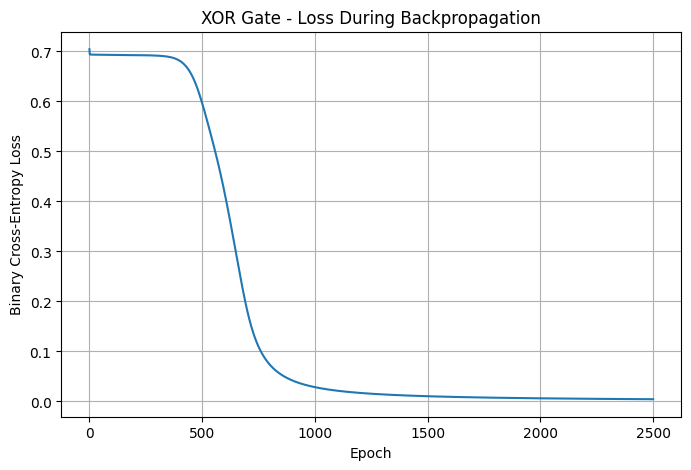

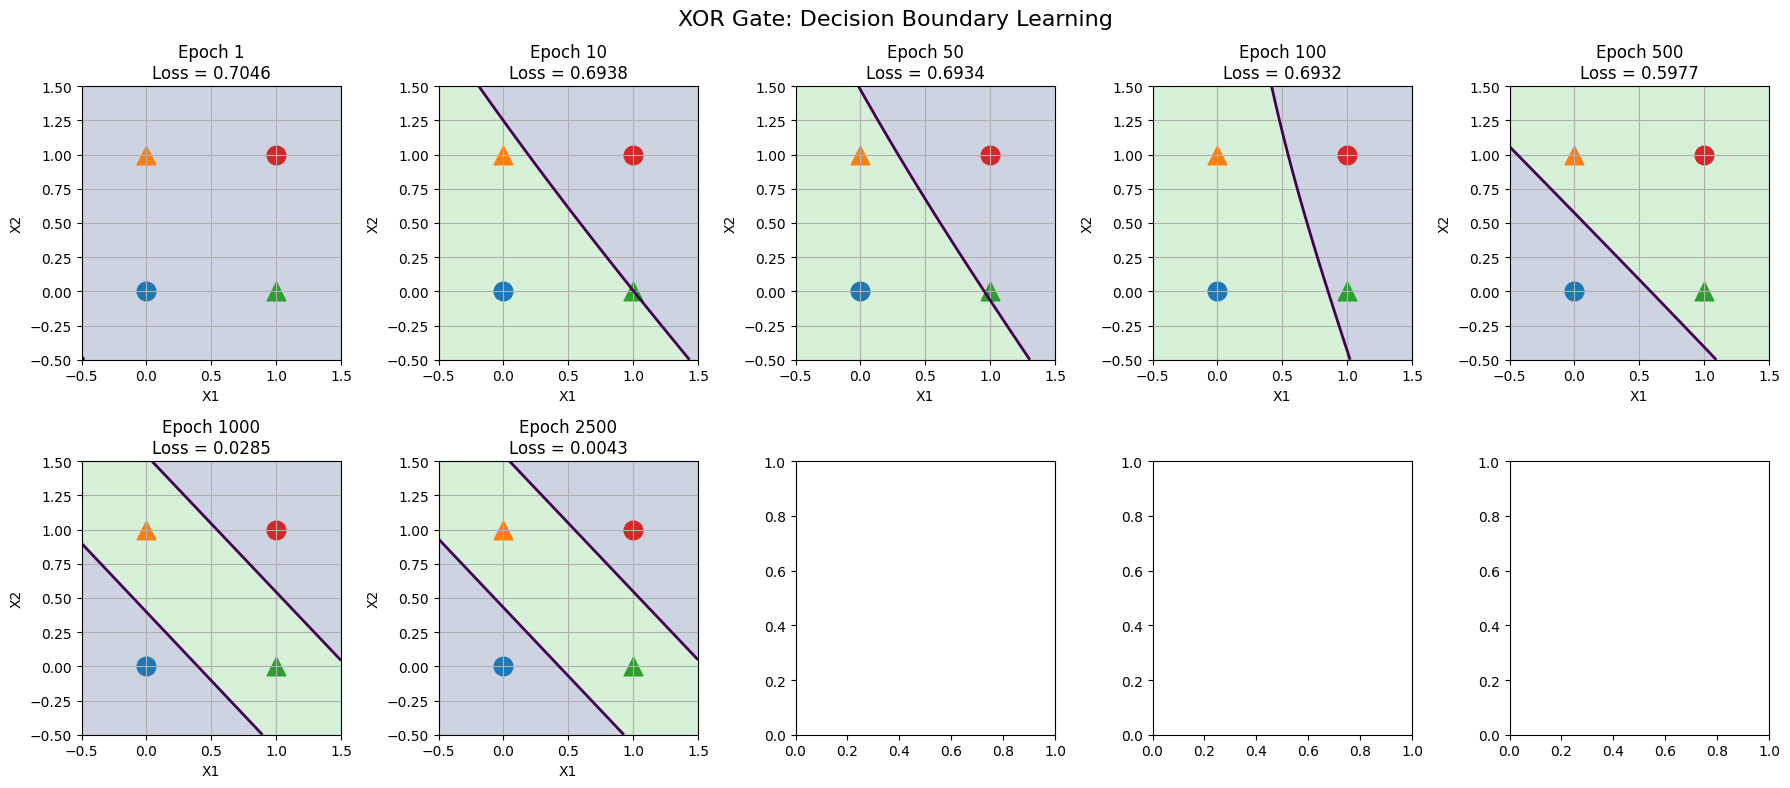

In [ ]:
# ============================================================
# XOR GATE USING BACKPROPAGATION
# WITH EPOCH-WISE VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. XOR DATASET
# ============================================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)


# ============================================================
# 2. SIGMOID FUNCTION
# ============================================================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Derivative of sigmoid
def sigmoid_derivative(a):
    return a * (1 - a)


# ============================================================
# 3. INITIALIZE NETWORK
#
# Input Layer  : 2 neurons
# Hidden Layer : 4 neurons
# Output Layer : 1 neuron
# ============================================================

np.random.seed(42)

input_neurons = 2
hidden_neurons = 4
output_neurons = 1

# Input -> Hidden
W1 = np.random.randn(input_neurons, hidden_neurons) * 0.5
b1 = np.zeros((1, hidden_neurons))

# Hidden -> Output
W2 = np.random.randn(hidden_neurons, output_neurons) * 0.5
b2 = np.zeros((1, output_neurons))


# ============================================================
# 4. TRAINING PARAMETERS
# ============================================================

learning_rate = 1.0
epochs = 2500

loss_history = []

# Epochs that will be visualized
visualize_epochs = [
    1, 10, 50, 100, 500,
    1000, 2500
]

history = []


# ============================================================
# 5. BACKPROPAGATION TRAINING
# ============================================================

for epoch in range(1, epochs + 1):

    # --------------------------------------------------------
    # FORWARD PROPAGATION
    # --------------------------------------------------------

    # Input -> Hidden
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    # Hidden -> Output
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)


    # --------------------------------------------------------
    # CALCULATE LOSS
    # --------------------------------------------------------

    loss = -np.mean(
        y * np.log(A2 + 1e-8)
        +
        (1 - y) * np.log(1 - A2 + 1e-8)
    )

    loss_history.append(loss)


    # --------------------------------------------------------
    # BACKPROPAGATION
    # --------------------------------------------------------

    # Output layer error
    dZ2 = A2 - y

    # Gradient for W2
    dW2 = np.dot(A1.T, dZ2) / len(X)

    # Gradient for output bias
    db2 = np.mean(dZ2, axis=0, keepdims=True)


    # Hidden layer error
    dA1 = np.dot(dZ2, W2.T)

    dZ1 = dA1 * sigmoid_derivative(A1)

    # Gradient for W1
    dW1 = np.dot(X.T, dZ1) / len(X)

    # Gradient for hidden bias
    db1 = np.mean(dZ1, axis=0, keepdims=True)


    # --------------------------------------------------------
    # UPDATE WEIGHTS
    # --------------------------------------------------------

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1


    # --------------------------------------------------------
    # SAVE PARAMETERS FOR VISUALIZATION
    # --------------------------------------------------------

    if epoch in visualize_epochs:

        history.append({
            "epoch": epoch,
            "W1": W1.copy(),
            "b1": b1.copy(),
            "W2": W2.copy(),
            "b2": b2.copy(),
            "loss": loss
        })


    # Display progress
    if epoch in [1, 10, 100, 1000, 2500]:

        print(
            f"Epoch: {epoch:5d} | Loss: {loss:.6f}"
        )


# ============================================================
# 6. FINAL PREDICTIONS
# ============================================================

Z1 = np.dot(X, W1) + b1
A1 = sigmoid(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)

predictions = (A2 >= 0.5).astype(int)


print("\n======================================")
print("FINAL XOR PREDICTIONS")
print("======================================")

print("X1   X2   Probability   Prediction   Target")
print("--------------------------------------------")

for i in range(len(X)):

    print(
        f"{int(X[i,0])}    "
        f"{int(X[i,1])}     "
        f"{A2[i,0]:.6f}       "
        f"{predictions[i,0]}           "
        f"{int(y[i,0])}"
    )


# ============================================================
# 7. PRINT FINAL WEIGHTS
# ============================================================

print("\n======================================")
print("FINAL LEARNED WEIGHTS")
print("======================================")

print("\nW1 (Input -> Hidden):")
print(W1)

print("\nb1 (Hidden Bias):")
print(b1)

print("\nW2 (Hidden -> Output):")
print(W2)

print("\nb2 (Output Bias):")
print(b2)


# ============================================================
# 8. VISUALIZE LOSS VS EPOCH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title(
    "XOR Gate - Loss During Backpropagation"
)

plt.grid(True)

plt.show()


# ============================================================
# 9. VISUALIZE OUTPUT AT DIFFERENT EPOCHS
# ============================================================

fig, axes = plt.subplots(
    2, 5,
    figsize=(18, 8)
)

for ax, record in zip(
    axes.ravel(),
    history
):

    # Parameters at this epoch
    W1_temp = record["W1"]
    b1_temp = record["b1"]
    W2_temp = record["W2"]
    b2_temp = record["b2"]

    # --------------------------------------------------------
    # Create a grid of points
    # --------------------------------------------------------

    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]

    # --------------------------------------------------------
    # Forward propagation on grid
    # --------------------------------------------------------

    hidden = sigmoid(
        np.dot(grid, W1_temp) + b1_temp
    )

    output = sigmoid(
        np.dot(hidden, W2_temp) + b2_temp
    )

    output = output.reshape(xx.shape)


    # --------------------------------------------------------
    # Plot decision regions
    # --------------------------------------------------------

    ax.contourf(
        xx,
        yy,
        output,
        levels=[0, 0.5, 1],
        alpha=0.25
    )

    # Decision boundary
    ax.contour(
        xx,
        yy,
        output,
        levels=[0.5],
        linewidths=2
    )


    # --------------------------------------------------------
    # Plot XOR points
    # --------------------------------------------------------

    for i in range(len(X)):

        if y[i, 0] == 0:

            ax.scatter(
                X[i, 0],
                X[i, 1],
                s=180,
                marker="o"
            )

        else:

            ax.scatter(
                X[i, 0],
                X[i, 1],
                s=180,
                marker="^"
            )


    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    ax.set_title(
        f"Epoch {record['epoch']}\n"
        f"Loss = {record['loss']:.4f}"
    )

    ax.grid(True)


plt.suptitle(
    "XOR Gate: Decision Boundary Learning",
    fontsize=16
)

plt.tight_layout()

plt.show()